In [13]:
import kagglehub
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [14]:
path = kagglehub.dataset_download(
    "fedesoriano/heart-failure-prediction"
)

df = pd.read_csv(f"{path}/heart.csv")

print("Dataset Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Dataset Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [15]:
df.info()

df.describe()

print("Missing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpea

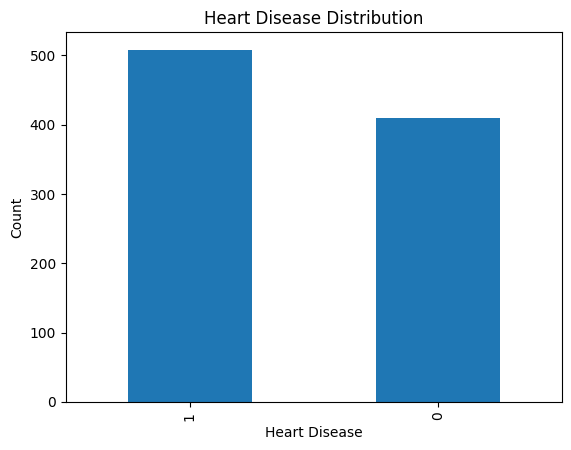

In [16]:
df["HeartDisease"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

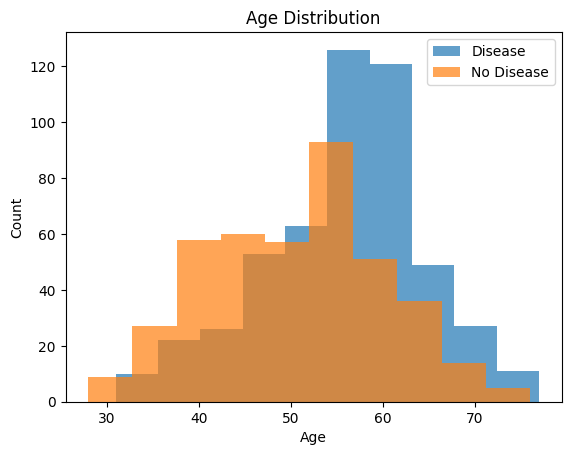

In [17]:
plt.hist(
    df[df["HeartDisease"] == 1]["Age"],
    alpha=0.7,
    label="Disease"
)

plt.hist(
    df[df["HeartDisease"] == 0]["Age"],
    alpha=0.7,
    label="No Disease"
)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.legend()

plt.show()

In [18]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X = pd.get_dummies(X, drop_first=True)

print(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
0   40        140          289          0    172      0.0   True   
1   49        160          180          0    156      1.0  False   
2   37        130          283          0     98      0.0   True   
3   48        138          214          0    108      1.5  False   
4   54        150          195          0    122      0.0   True   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  \
0               True              False             False               True   
1              False               True             False               True   
2               True              False             False              False   
3              False              False             False               True   
4              False               True             False               True   

   RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  
0          False             False          F

In [19]:
rf_default = RandomForestClassifier(
    random_state=42
)

rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

print(
    "Baseline Accuracy:",
    accuracy_score(y_test, y_pred_default)
)

Baseline Accuracy: 0.875


In [20]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Recall:")
print(grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Best Recall:
0.9014161220043574


In [21]:
y_pred_rf = best_model.predict(X_test)
y_prob_rf = best_model.predict_proba(X_test)[:, 1]

In [22]:
print(classification_report( y_test, y_pred_rf ))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        82
           1       0.89      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



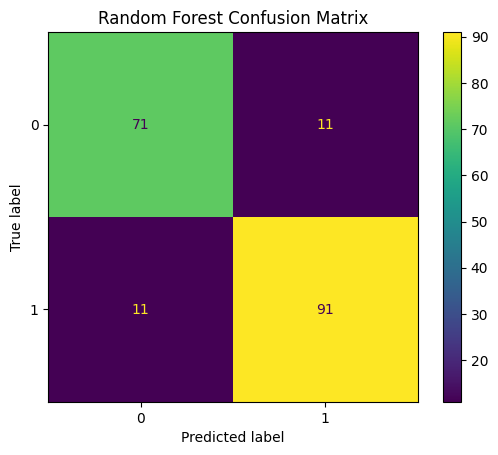

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

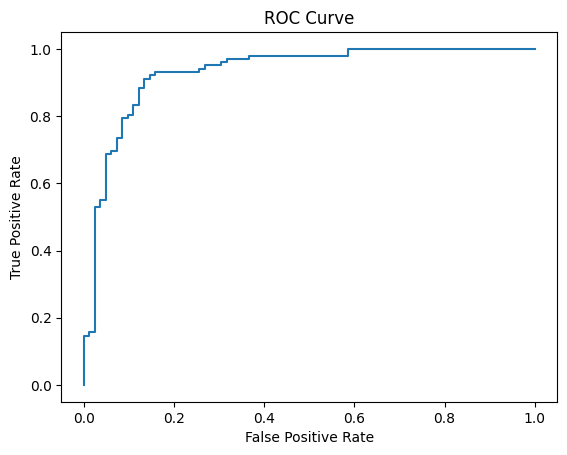

In [24]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

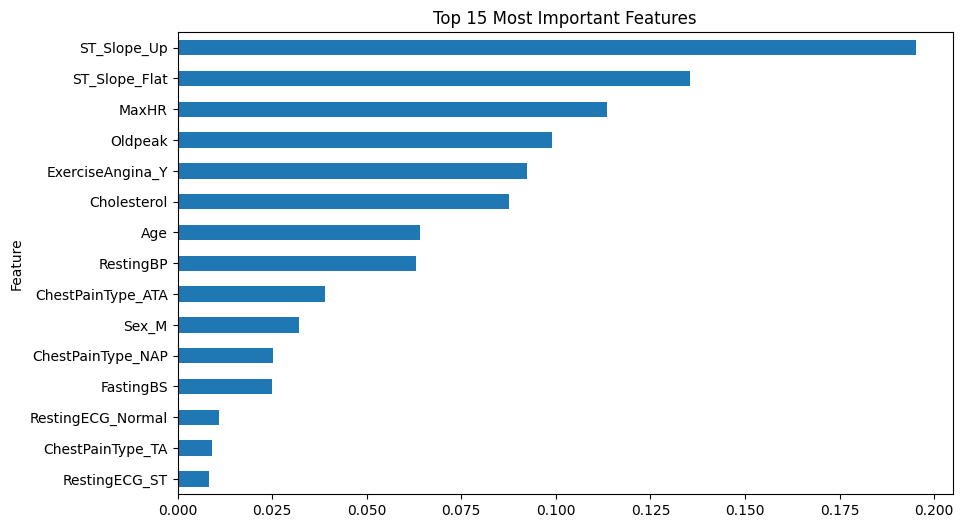

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

feature_importance.head(15).sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(10,6)
)

plt.title(
    "Top 15 Most Important Features"
)

plt.show()

In [26]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_model.fit(
    X_train,
    y_train
)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

print(classification_report(
    y_test,
    y_pred_lr
))

print(
    "AUC:",
    roc_auc_score(
        y_test,
        y_prob_lr
    )
)

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

AUC: 0.9296987087517934


In [27]:
sgd_model = make_pipeline(
    StandardScaler(),
    SGDClassifier(
        random_state=42
    )
)

sgd_model.fit(
    X_train,
    y_train
)

y_pred_sgd = sgd_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_sgd
))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        82
           1       0.91      0.85      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [28]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "SGD"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_rf
        ),
        accuracy_score(
            y_test,
            y_pred_lr
        ),
        accuracy_score(
            y_test,
            y_pred_sgd
        )
    ]
})

results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy
1,Logistic Regression,0.885870
0,Random Forest,0.880435
2,SGD,0.869565
